In [2]:
import kaggle

# تنزيل dataset
kaggle.api.dataset_download_files(
    'apollo2506/eurosat-dataset',
    path='./data',
    unzip=True
)

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
Dataset downloaded!


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork
from PIL import Image
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import datasets,transforms

In [4]:
custom_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
])

In [5]:
import os
from torchvision import datasets

# رح نبحث داخل مجلد data الموجود عندك
search_dir = 'data'
correct_base_dir = None

for root, dirs, files in os.walk(search_dir):
    # إذا لقينا مجلد الغابات والأنهار، معناته إحنا في المكان الصح
    if 'Forest' in dirs and 'River' in dirs:
        correct_base_dir = root
        break

if correct_base_dir:
    print(f"🎉 مسكناه! المسار الصحيح للصور هو:\n{correct_base_dir}\n")
    
    # تحديث المسار الأساسي
    base_dir = correct_base_dir
    
    # تشغيل مصنع البيانات (ImageFolder)
    imagefolder_dataset = datasets.ImageFolder(root=base_dir, transform=custom_transform)
    print(f"✅ مبروك! تم تحميل {len(imagefolder_dataset)} صورة بنجاح!")
    print(f"📂 الكلاسات اللي لقطها الموديل هي: {imagefolder_dataset.classes}")
else:
    print("❌ مجلد data موجود، بس الصور مش جواه مباشرة! محتويات مجلد data هي:")
    print(os.listdir('data'))

🎉 مسكناه! المسار الصحيح للصور هو:
data/EuroSAT

✅ مبروك! تم تحميل 27000 صورة بنجاح!
📂 الكلاسات اللي لقطها الموديل هي: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
import random
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)   

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark     = False 

In [7]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} — main process is now deterministic.")

Global seed set to 42 — main process is now deterministic.


In [8]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed) 
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

In [9]:
from torch.utils.data import random_split
train_size = int(0.8 * len(imagefolder_dataset))
val_size = len(imagefolder_dataset) - train_size

train_data, val_data = random_split(
    imagefolder_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # عشان نحافظ على ثبات النتائج
)

In [10]:
train_transform = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.RandomRotation(40),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomAffine(0, shear=0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])


In [11]:
val_transform = transforms.Compose([transforms.Resize((64, 64)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])


In [12]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

In [13]:
from torch import nn

# إذا الكرت متعرف رح يختار cuda، وإذا لأ رح يرجع للـ cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# سطرين عشان يطبعلك شو الكرت اللي لقطو ويتطمن قلبك
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

model = nn.Sequential(
    nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(32),
    nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(64),
    nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(128),
    nn.Conv2d(128,256,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(256),
    nn.Conv2d(256,512,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(512),
    nn.Conv2d(512,1024,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),nn.BatchNorm2d(1024),

    nn.AdaptiveAvgPool2d(1),nn.Flatten(),
    nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
    nn.Linear(2048,10)
).to(device)

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}

print("Created Model. Now training the model...")

Created Model. Now training the model...


In [15]:
print(f"Training on : ==={device}=== with batch size: {32} & lr: {0.001}")

epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss,train_correct,train_total = 0.0 ,0.0 ,0.0
    for input,label in train_loader:
        input = input.to(device)
        label = label.to(device)
        output = model(input)
        loss = criterion(output,label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(output, dim=1)
        train_correct += (preds == label).sum().item()
        train_total += label.size(0)
    
    model.eval()
    val_loss,val_correct,val_total = 0.0 ,0.0 ,0.0
    with torch.no_grad():
        for input,label in val_loader:
            input = input.to(device)
            label = label.to(device)
            output = model(input)
            loss = criterion(output,label)
            val_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            val_correct += (preds == label).sum().item()
            val_total += output.size(0)
    # Store metrics
    loss_history['train'].append(train_loss/len(train_loader))
    loss_history['val'].append(val_loss/len(val_loader))
    acc_history['train'].append(train_correct/train_total)
    acc_history['val'].append(val_correct/val_total)
    
    #print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss_history['train'][-1]:.4f} | Val Loss: {loss_history['val'][-1]:.4f}")
    print(f"Train Acc: {acc_history['train'][-1]:.4f} | Val Acc: {acc_history['val'][-1]:.4f}")
print("Trained Model. Now evaluating the model...")

Training on : ===cuda=== with batch size: 32 & lr: 0.001
Train Loss: 1.0834 | Val Loss: 1.4781
Train Acc: 0.6327 | Val Acc: 0.6037
Train Loss: 0.8557 | Val Loss: 0.5694
Train Acc: 0.7223 | Val Acc: 0.8033
Train Loss: 0.7029 | Val Loss: 0.5832
Train Acc: 0.7716 | Val Acc: 0.7881
Train Loss: 0.6360 | Val Loss: 1.3283
Train Acc: 0.7979 | Val Acc: 0.7163
Train Loss: 0.5488 | Val Loss: 0.4718
Train Acc: 0.8266 | Val Acc: 0.8454
Trained Model. Now evaluating the model...


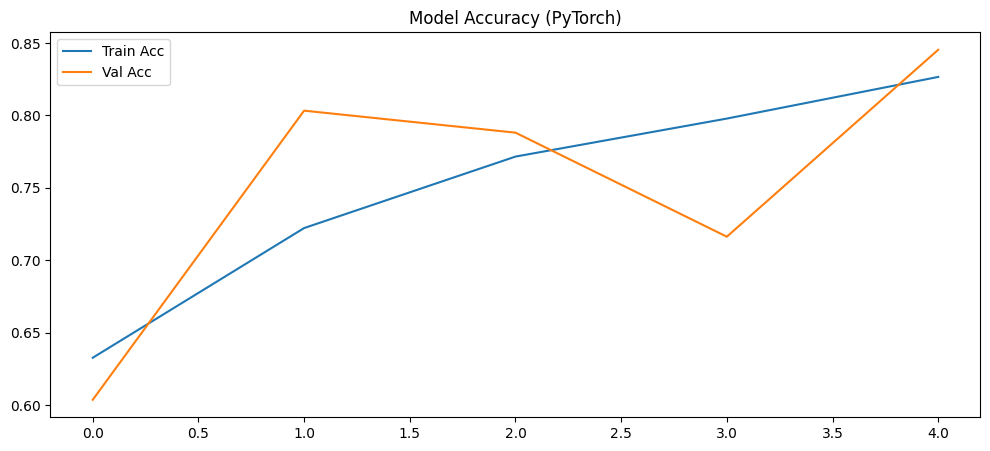

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(acc_history['train'], label='Train Acc')
plt.plot(acc_history['val'], label='Val Acc')
plt.title('Model Accuracy (PyTorch)')
plt.legend()
plt.show()

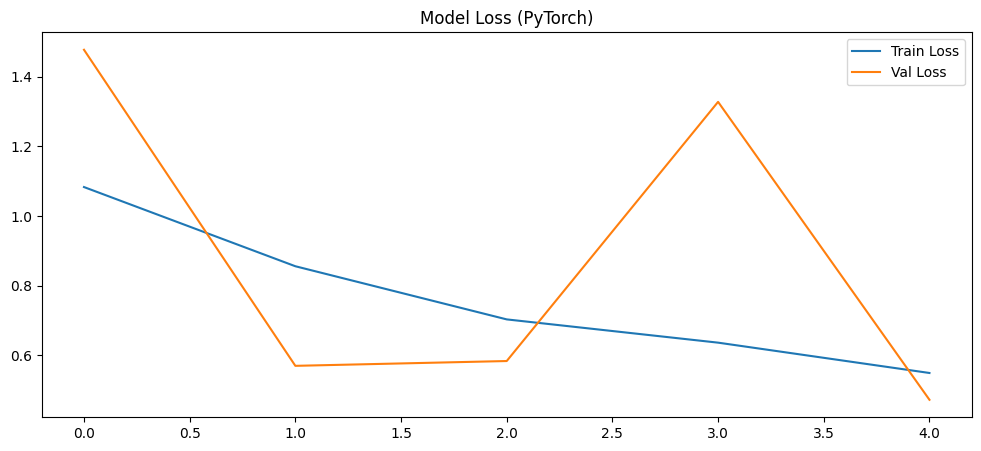

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Val Loss')
plt.title('Model Loss (PyTorch)')
plt.legend()
plt.show()

In [18]:
import torch
from torch import nn
from torchvision import models

# 1. استدعاء الموديل العملاق (ResNet18) مع أوزانه الذكية الجاهزة
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. تعديل "الرأس" (الطبقة الأخيرة):
# الموديل الأصلي يخرج 1000 فئة، نحن نحتاج 10 فقط!
num_features = model.fc.in_features # نستخرج عدد الخلايا المربوطة بالطبقة الأخيرة
model.fc = nn.Linear(num_features, 10) # نضع طبقتنا الجديدة لـ 10 كلاسات

# 3. إرسال الموديل لكرت الشاشة
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 4. دالة الخسارة
criterion = nn.CrossEntropyLoss()

# 5. المُحسّن (Optimizer) مع السلاح الجديد (weight_decay) لتقليل الـ Overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 6. الذكاء الإضافي: مُجدول معدل التعلم (Scheduler)
# إذا لم يتحسن الموديل لمدة جولتين (patience=2)، سيقوم بضرب الـ lr بـ 0.1 ليصبح أبطأ وأدق
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

print("✅ تم تجهيز ResNet18 وتعديل طبقته الأخيرة بنجاح!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/mahmoudahmad/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 23.5MB/s]


✅ تم تجهيز ResNet18 وتعديل طبقته الأخيرة بنجاح!


In [19]:
import torch
import time

# 1. تجهيز المتغيرات لتسجيل النتائج
loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}

best_loss = float('inf') # لمراقبة أفضل نسخة من الموديل
epochs = 10 # عدد الجولات (10 كافية جداً مع ResNet)

print(f"🚀 بدء التدريب على: ==={device}=== باستخدام ResNet18")
print("-" * 50)

for epoch in range(epochs):
    start_time = time.time()
    
    # ==============================
    # 🎯 1. مرحلة التدريب (Training)
    # ==============================
    model.train()
    train_loss, train_correct, train_total = 0.0, 0.0, 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # تصفير التدرجات
        outputs = model(inputs) # التوقع
        loss = criterion(outputs, labels) # حساب الخطأ
        loss.backward() # العودة للخلف (Backpropagation)
        optimizer.step() # تحديث الأوزان
        
        # تجميع النتائج
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_total

    # ==============================
    # 🧪 2. مرحلة التقييم (Validation)
    # ==============================
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0.0, 0.0
    
    with torch.no_grad(): # إيقاف حساب التدرجات (لتسريع التقييم وتوفير الذاكرة)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_total

    # ==============================
    # 📊 3. تسجيل النتائج وتحديث الـ Scheduler
    # ==============================
    loss_history['train'].append(avg_train_loss)
    loss_history['val'].append(avg_val_loss)
    acc_history['train'].append(avg_train_acc)
    acc_history['val'].append(avg_val_acc)
    
    # السلاح السري: نخبر الـ Scheduler بقيمة الخسارة ليقرر هل يقلل سرعة التعلم أم لا
    scheduler.step(avg_val_loss)
    
    # ==============================
    # 💾 4. حفظ أفضل موديل (Model Checkpointing)
    # ==============================
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_resnet_eurosat.pth')
        saved_msg = " 🌟 (تم حفظ أفضل موديل!)"
    else:
        saved_msg = ""
        
    # حساب وقت الجولة
    epoch_time = time.time() - start_time
    
    # طباعة التقرير النهائي لكل جولة
    current_lr = optimizer.param_groups[0]['lr'] # لمعرفة سرعة التعلم الحالية
    print(f"Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.0f}s | LR: {current_lr}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.4f}{saved_msg}")
    print("-" * 50)

print("🎉 انتهى التدريب بنجاح! الموديل الخارق جاهز الآن.")

🚀 بدء التدريب على: ===cuda=== باستخدام ResNet18
--------------------------------------------------
Epoch [1/10] | Time: 18s | LR: 0.001
Train Loss: 0.6004 | Train Acc: 0.8081
Val Loss:   0.3730 | Val Acc:   0.8859 🌟 (تم حفظ أفضل موديل!)
--------------------------------------------------
Epoch [2/10] | Time: 15s | LR: 0.001
Train Loss: 0.4005 | Train Acc: 0.8709
Val Loss:   0.4192 | Val Acc:   0.8681
--------------------------------------------------
Epoch [3/10] | Time: 18s | LR: 0.001
Train Loss: 0.3220 | Train Acc: 0.8943
Val Loss:   0.2733 | Val Acc:   0.9065 🌟 (تم حفظ أفضل موديل!)
--------------------------------------------------
Epoch [4/10] | Time: 15s | LR: 0.001
Train Loss: 0.3057 | Train Acc: 0.9018
Val Loss:   0.2051 | Val Acc:   0.9339 🌟 (تم حفظ أفضل موديل!)
--------------------------------------------------
Epoch [5/10] | Time: 17s | LR: 0.001
Train Loss: 0.2902 | Train Acc: 0.9045
Val Loss:   0.2715 | Val Acc:   0.9074
--------------------------------------------------
Ep